In [1]:
#suppressing a warning - UserWarning: Wswiglal-redir-stdio
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import lal as _lal

import sys

sys.path.insert(0, "../")
from src.regular_precession import *
from src.systems_lib import *
from src.mismatch_n_SNR import *
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 200

In [2]:
# Define the default parameters for the system 1
default_precession_params_sys1 = redshifted_new_params(0.3, default_precession_params_sys1)
default_precession_params_sys1_NP = redshifted_new_params(0.3, default_precession_params_sys1_NP)

# Define the default parameters for the system 2
default_precession_params_sys2 = redshifted_new_params(0.3, default_precession_params_sys2)
default_precession_params_sys2_NP = redshifted_new_params(0.3, default_precession_params_sys2_NP)

# Define the default parameters for the system 3
default_precession_params_sys3 = redshifted_new_params(0.3, default_precession_params_sys3)
default_precession_params_sys3_NP = redshifted_new_params(0.3, default_precession_params_sys3_NP)


In [3]:
rc_params = {
    'axes.grid': False,
    'axes.labelsize': 24,
    'axes.linewidth':1.75,
    'axes.titlesize': 32,
    'font.size': 24,
    'legend.fontsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    # Custom fonts? 
    'font.family': 'serif',
    'font.sans-serif': ['Bitstream Vera Sans'],
    'font.serif': ['Times New Roman'],
    # Uncomment to use LaTeX
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{amsfonts}',
    'text.usetex':True,
    'patch.force_edgecolor':True,
}
plt.rcParams.update(rc_params)

# Colours
dodgerblue       = '#1E90FF'
royalsocietyred  = '#BA0C2F'
grgreen          = '#4DAF4A'

Cut-off frequency: 147.21 Hz


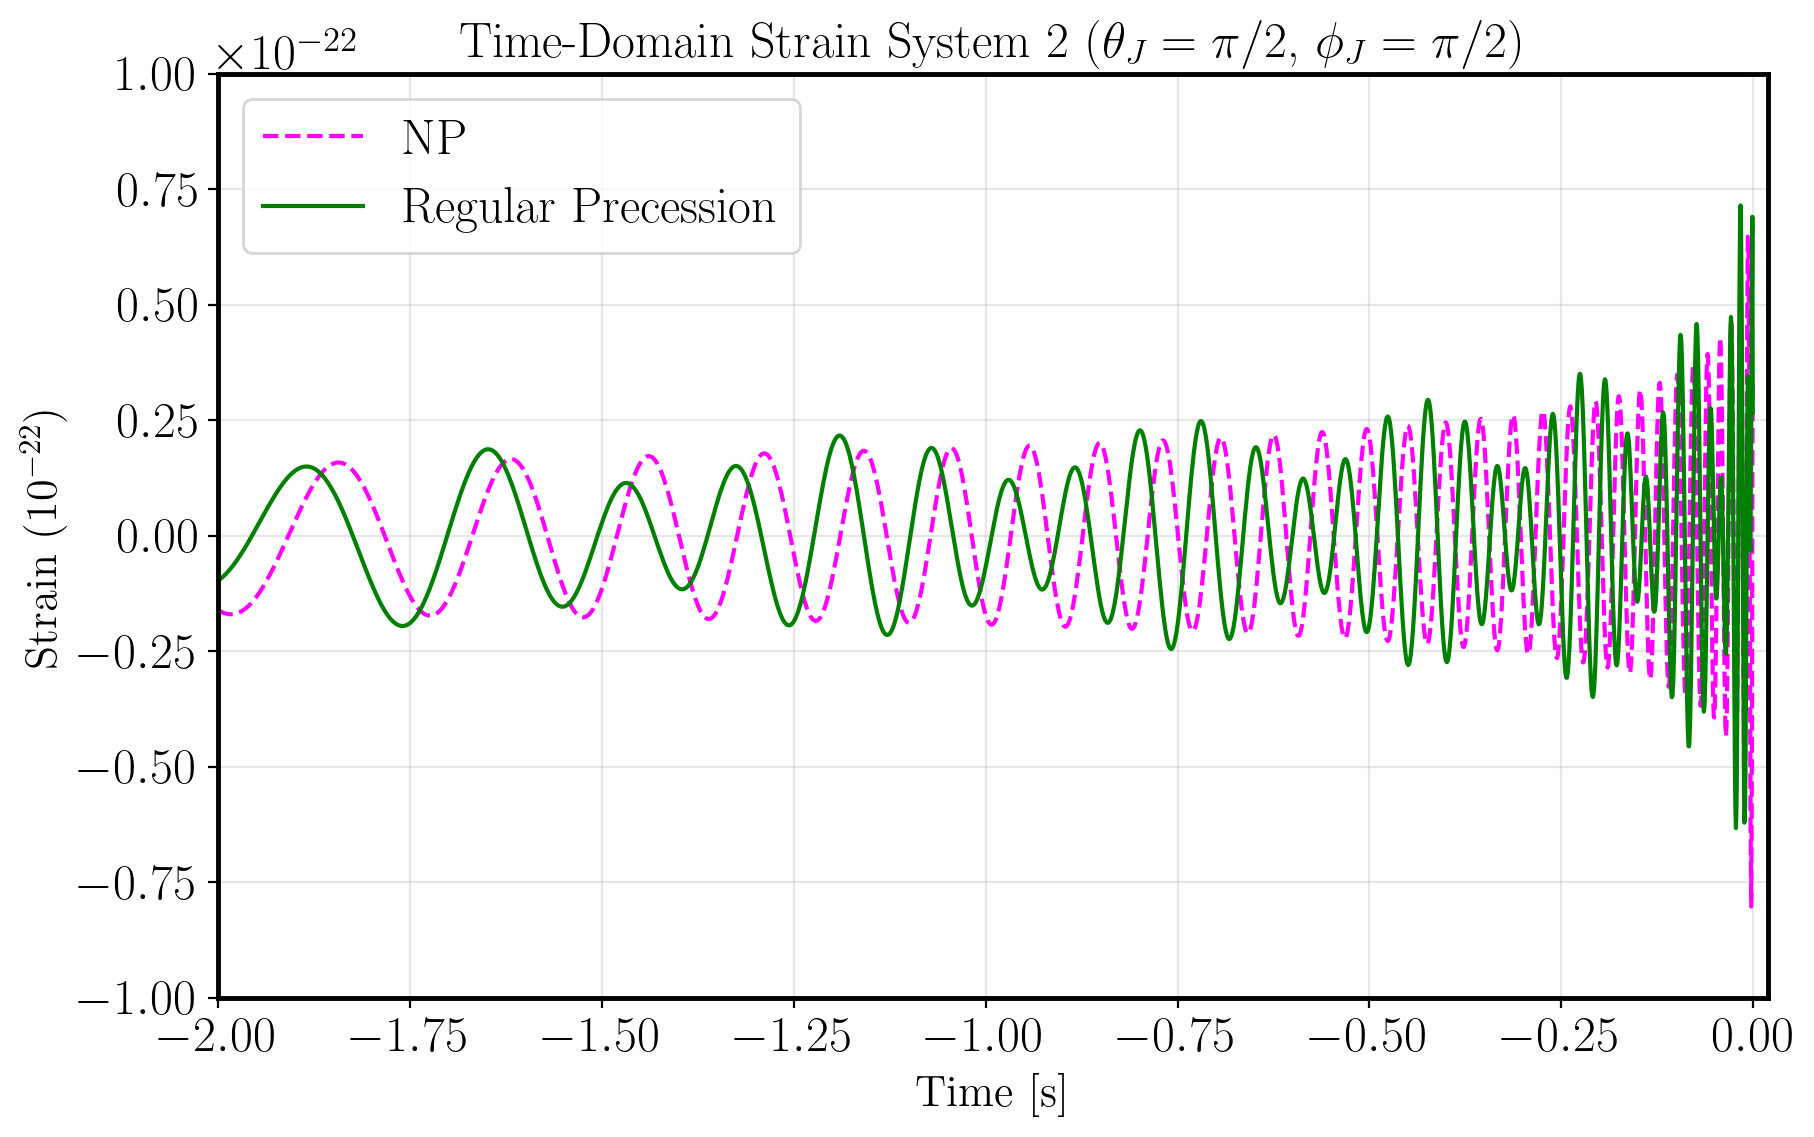

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.types import FrequencySeries, TimeSeries
from pycbc.waveform import utils as wfutils
import pycbc.fft

# --- Define your parameters ---
params = default_precession_params_sys2_NP.copy()
z = 0.3
params['mcz'] = 10 * solar_mass
params = redshifted_new_params(z, params)

# --- Set up frequency array ---
f_low = 20.0          # Hz, lower frequency cutoff
delta_f = 0.25        # Hz, frequency resolution
f_high = 1024.0       # Hz, upper frequency cutoff

model = Regular_precession(params)
f_cut = model.get_f_cut()
print(f"Cut-off frequency: {f_cut:.2f} Hz")

# Clip f_high to just below f_cut to avoid divergence near coalescence
f_high = max(f_high, f_cut)
freqs = np.arange(f_low, f_high, delta_f)

# --- Compute frequency-domain strain ---
def make_timeseries(model, freqs, f_low, f_high, delta_f):
    """Compute frequency-domain strain, zero-pad, IFFT, and reverse time axis."""
    
    # Get strain as numpy array (not FrequencySeries)
    h_f = model.precessing_strain(freqs, delta_f=delta_f, frequencySeries=True).numpy()
    
    # Zero-pad from 0 Hz up to f_high
    n_total = int(round(f_high / delta_f)) + 1                                    
    h_f_full = np.zeros(n_total, dtype=complex)
    idx_low  = int(round(f_low / delta_f))
    h_f_full[idx_low : idx_low + len(h_f)] = h_f

    # IFFT to time domain
    hp_fs = FrequencySeries(h_f, delta_f=delta_f)
    hp_ts = hp_fs.to_timeseries()

    # Reverse time so merger is at t=0, inspiral at negative times
    hp_ts_reversed = TimeSeries(
        hp_ts.numpy()[::-1],
        delta_t=hp_ts.delta_t,
        epoch=-hp_ts.duration   # duration = N * delta_t, so t runs from -T to 0
    )
    return hp_ts_reversed

hp_ts = make_timeseries(model, freqs, f_low, f_high, delta_f)

params_RP = params.copy()
params_RP['theta_tilde'] = 8
params_RP['omega_tilde'] = 3
model_RP = Regular_precession(params_RP)
hp_ts_RP= make_timeseries(model_RP, freqs, f_low, f_high, delta_f)

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.plot(hp_ts.sample_times, hp_ts.numpy(), label='NP', color='magenta', linestyle='--')
plt.plot(hp_ts_RP.sample_times, hp_ts_RP.numpy(), label='Regular Precession', color='green', linestyle='-')
plt.xlim(-2, 0.02)
plt.ylim(-1e-22, 1e-22)
plt.xlabel('Time [s]', fontsize=16)
plt.ylabel('Strain ($10^{-22}$)', fontsize=16)
plt.title(r'Time-Domain Strain System 2 ($\theta_J = \pi/2$, $\phi_J = \pi/2$)', fontsize=18)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

fig = plt.gcf()
fig.savefig('figs/example_time_domain_RP.pdf', bbox_inches='tight')

Cut-off frequency: 147.21 Hz


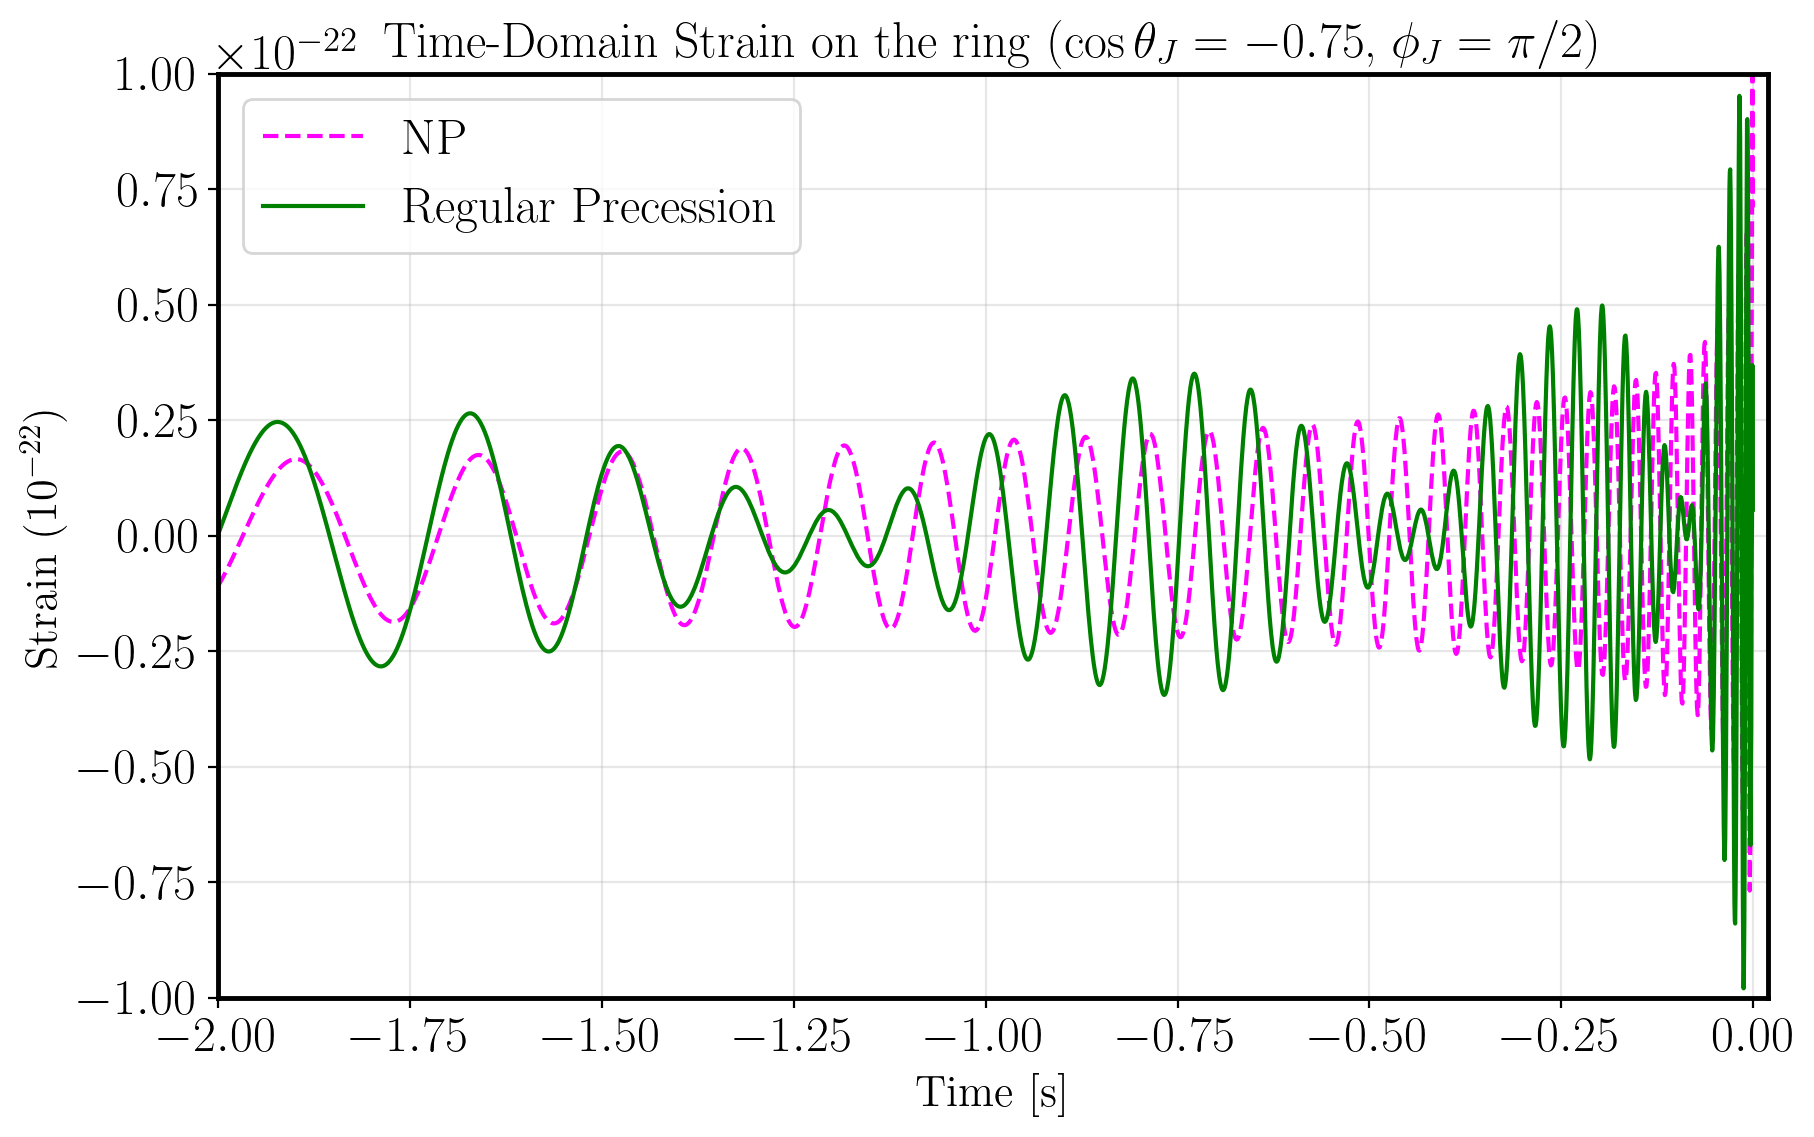

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.types import FrequencySeries, TimeSeries
from pycbc.waveform import utils as wfutils
import pycbc.fft

# --- Define your parameters ---
params = default_precession_params_sys2_NP.copy()
params['theta_J'] = np.arccos(-0.75)
params['phi_J'] = np.pi/2
z = 0.3
params['mcz'] = 10 * solar_mass
params = redshifted_new_params(z, params)

# --- Set up frequency array ---
f_low = 20.0          # Hz, lower frequency cutoff
delta_f = 0.25        # Hz, frequency resolution
f_high = 1024.0       # Hz, upper frequency cutoff

model = Regular_precession(params)
f_cut = model.get_f_cut()
print(f"Cut-off frequency: {f_cut:.2f} Hz")

# Clip f_high to just below f_cut to avoid divergence near coalescence
f_high = max(f_high, f_cut)
freqs = np.arange(f_low, f_high, delta_f)

# --- Compute frequency-domain strain ---
def make_timeseries(model, freqs, f_low, f_high, delta_f):
    """Compute frequency-domain strain, zero-pad, IFFT, and reverse time axis."""
    
    # Get strain as numpy array (not FrequencySeries)
    h_f = model.precessing_strain(freqs, delta_f=delta_f, frequencySeries=True).numpy()
    
    # Zero-pad from 0 Hz up to f_high
    n_total = int(round(f_high / delta_f)) + 1                                    
    h_f_full = np.zeros(n_total, dtype=complex)
    idx_low  = int(round(f_low / delta_f))
    h_f_full[idx_low : idx_low + len(h_f)] = h_f

    # IFFT to time domain
    hp_fs = FrequencySeries(h_f, delta_f=delta_f)
    hp_ts = hp_fs.to_timeseries()

    # Reverse time so merger is at t=0, inspiral at negative times
    hp_ts_reversed = TimeSeries(
        hp_ts.numpy()[::-1],
        delta_t=hp_ts.delta_t,
        epoch=-hp_ts.duration   # duration = N * delta_t, so t runs from -T to 0
    )
    return hp_ts_reversed

hp_ts = make_timeseries(model, freqs, f_low, f_high, delta_f)

params_RP = params.copy()
params_RP['theta_tilde'] = 8
params_RP['omega_tilde'] = 3
model_RP = Regular_precession(params_RP)
hp_ts_RP= make_timeseries(model_RP, freqs, f_low, f_high, delta_f)

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.plot(hp_ts.sample_times, hp_ts.numpy(), label='NP', color='magenta', linestyle='--')
plt.plot(hp_ts_RP.sample_times, hp_ts_RP.numpy(), label='Regular Precession', color='green', linestyle='-')
plt.xlim(-2, 0.02)
plt.ylim(-1e-22, 1e-22)
plt.xlabel('Time [s]', fontsize=16)
plt.ylabel('Strain ($10^{-22}$)', fontsize=16)
plt.title(r'Time-Domain Strain on the ring ($\cos\theta_J = -0.75$, $\phi_J = \pi/2$)', fontsize=18)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

fig = plt.gcf()
#fig.savefig('figs/example_time_domain_RP.pdf', bbox_inches='tight')

In [6]:
import numpy as np

def time_in_band(Mc_solar, f_low=20.0):
    """
    Leading-order PN inspiral time from f_low to merger.
    Mc_solar: chirp mass in solar masses
    f_low: lower frequency cutoff in Hz
    Returns time in seconds.
    """
    G  = 6.674e-11
    c  = 3e8
    Ms = 1.989e30        # solar mass in kg
    
    Mc = Mc_solar * (1+ z) * Ms
    tau = (5/256) * (c**5 / G**(5/3)) * Mc**(-5/3) * (np.pi * f_low)**(-8/3)
    return tau

Mc = 10   # solar masses, e.g. equal-mass 10+10 BBH
print(f"Time in band: {time_in_band(Mc, f_low=20):.1f} s")

Time in band: 3.1 s
